# Portfolio Metrics

*Note:* The `massive` library was installed with the Python 3.13.3 kernel, so use that one.

In [92]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import date, timedelta
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import contextlib
import io

In [66]:
from copulae import GaussianCopula, StudentCopula

In [126]:
tickers = [
    "SPY", "QQQ", "DFAI", "META", "JPM", "MSFT",
    "AMZN", "NFLX", "GOOG", "ORCL", 
    "GLD", "COST", "VDC", "XLU"
]

years = 5
end_date = date.today()
start_date = end_date - timedelta(days=years * 365)

In [127]:
def get_daily_bars(symbols, start_date, end_date):
    """
    Fetch daily OHLCV data from Yahoo Finance using yfinance.

    Returns:
        data: long DataFrame with columns:
              symbol, open, high, low, close, adj_close, volume
        close_prices: wide DataFrame of close prices by symbol
    """

    raw = yf.download(
        tickers=symbols,
        start=start_date.isoformat(),
        end=end_date.isoformat(),
        interval="1d",
        auto_adjust=False,
        group_by="ticker",
        progress=True,
        threads=True
    )

    all_dfs = []

    for symbol in symbols:
        try:
            df = raw[symbol].copy()
        except KeyError:
            print(f"No data returned for {symbol}")
            continue

        if df.empty:
            print(f"No data returned for {symbol}")
            continue

        df = df.rename(columns={
            "Open": "open",
            "High": "high",
            "Low": "low",
            "Close": "close",
            "Adj Close": "adj_close",
            "Volume": "volume"
        })

        df["symbol"] = symbol
        df.index.name = "timestamp"

        df = df[["symbol", "open", "high", "low", "close", "adj_close", "volume"]]
        all_dfs.append(df)

    data = pd.concat(all_dfs).sort_index()

    close_prices = data.pivot_table(
        values="close",
        index=data.index,
        columns="symbol"
    )

    return data, close_prices


data, close_prices = get_daily_bars(tickers, start_date, end_date)

print(close_prices.tail())

[*********************100%***********************]  14 of 14 completed

symbol            AMZN        COST       DFAI         GLD        GOOG  \
timestamp                                                               
2026-06-25  227.009995  942.239990  41.060001  369.459991  342.190002   
2026-06-26  232.690002  952.539978  40.900002  373.630005  334.690002   
2026-06-29  240.139999  946.679993  41.139999  368.579987  351.279999   
2026-06-30  238.339996  935.469971  41.250000  368.380005  353.329987   
2026-07-01  241.699997  924.669983  41.090000  370.600006  357.890015   

symbol             JPM        META        MSFT       NFLX        ORCL  \
timestamp                                                               
2026-06-25  335.119995  542.869995  352.829987  70.900002  152.460007   
2026-06-26  329.049988  550.250000  372.970001  73.809998  148.529999   
2026-06-29  329.390015  562.599976  368.570007  73.779999  147.759995   
2026-06-30  327.329987  563.289978  373.019989  71.400002  146.550003   
2026-07-01  334.070007  612.909973  384.279999  74

In [128]:
def max_drawdown(prices):
    roll_max = prices.cummax()
    drawdown = prices / roll_max - 1
    return drawdown.min()

In [131]:
def copula_num_params(cop, family_name, dim):
    family_name = family_name.lower()

    if family_name == "gaussian":
        return dim * (dim - 1) // 2

    elif family_name == "student_t":
        return len(cop.params.rho) + 1   # pairwise correlations and degrees of freedom

    elif family_name in ["clayton", "gumbel", "frank"]:
        return 1

    else:
        return np.asarray(cop.params).size

In [132]:
def extract_params(cop, name):
    name = name.lower()

    if name == "student_t":
        return {
            "df": float(cop.params.df),
            "rho": np.asarray(cop.params.rho).copy()
        }

    elif name == "gaussian":
        return {
            "rho": np.asarray(cop.params).copy()
        }

    else:
        return cop.params

In [104]:
def num_params(cop, name):
            name = name.lower()
            if name == "gaussian":
                return d * (d - 1) // 2
            elif name == "student_t":
                return len(cop.params.rho) + 1
            else:
                return np.asarray(cop.params).size

In [ ]:
class Portfolio:
    '''
    Fields:
        self.tickers is a list of security tickers in the portfolio
        self.weights is a dictionary with ticker keys and portfolio weight values
        self.data is a DataFrame of price data for the securities in the portfolio

    Dependencies:
        numpy as np
        pandas as pd
        pyvinecopulib as pv
    '''

    def __init__(self, tickers, df, weights={}):
        self.tickers = tickers
        self.weights = weights
        self.data = df


    def holding_data(self, holding):
        df = self.data
        if holding != 'all':
            df = df[holding]
        return df


    def returns(self, holding='all', log=True):
        '''
        The daily log returns (i.e. log(P[t]/P[t-1]) = log(P[t]) - log(P[t-1]) )
        or the daily ordinary returns if log=False (i.e. P[t]/P[t-1] - 1 ).
        '''
        df = self.holding_data(holding)
        if log:
            return np.log(df).diff().dropna()
        else:
            return df.pct_change().dropna()
        

    def uni_summary(self, holding='all', log=False, tail=0.05):
        '''
        Returns a univariate summary of the returns of each security (individually), including:
            - the annualized mean and volatility, 
            - the skew and excess kurtosis, and 
            - some tail risk metrics (VaR, ES/CVaR, MaxDD).
        '''
        df = self.returns(holding=holding, log=log)
        means = df.mean()

        d = {}
        if log:
            d['Mean (Ann.)'] = means * 252
        else: 
            d['Mean (Ann.)'] = (1 + means)**252 - 1 
            # Note: this is equivalent to the expression in the log=True case
            #       although we break up the cases to take advantage of the
            #       simplified formula for log=True.
        d['Volatility (Ann.)'] = df.std() * np.sqrt(252)
        d['Skew'] = df.skew()
        d['Kurtosis (Excess)'] = df.kurtosis()
        d[f'VaR({tail*100:.1f}%)'] = df.quantile(tail) 
        d[f'ES({tail*100:.1f}%)'] = df.apply(lambda col: col[col <= col.quantile(tail)].mean())
        d[f'MaxDD'] = max_drawdown( (1+df).cumprod() )

        return pd.DataFrame(d).T
    

    def dependence(self, type="corr", holding="all", log=False, tail=0.05):
        """
        Dependence measures between return series.

        type options:
            - "corr": Pearson correlation
            - "cov": covariance
            - "spearman": rank correlation
            - "kendall": Kendall's tau
            - "lower_tail": empirical lower tail dependence
            - "upper_tail": empirical upper tail dependence
            - "all": dictionary of several dependence measures
        """

        df = self.returns(holding=holding, log=log).dropna()

        if type == "corr":
            return df.corr(method="pearson")
        elif type == "cov":
            return df.cov()
        elif type == "spearman":
            return df.corr(method="spearman")
        elif type == "kendall":
            return df.corr(method="kendall")
        elif type in ["lower_tail", "upper_tail"]:
            ranks = df.rank(method="average") / (len(df) + 1)
            out = pd.DataFrame(
                np.eye(len(df.columns)),
                index=df.columns,
                columns=df.columns
            )
            for i in df.columns:
                for j in df.columns:
                    if i == j:
                        continue
                    if type == "lower_tail":
                        # P(U_i <= q | U_j <= q)
                        numerator = ((ranks[i] <= tail) & (ranks[j] <= tail)).mean()
                        denominator = (ranks[j] <= tail).mean()
                    else:
                        # P(U_i >= 1-q | U_j >= 1-q)
                        numerator = ((ranks[i] >= 1 - tail) & (ranks[j] >= 1 - tail)).mean()
                        denominator = (ranks[j] >= 1 - tail).mean()
                    out.loc[i, j] = numerator / denominator if denominator > 0 else np.nan
            return out
        elif type == "all":
            return {
                "pearson_corr": df.corr(method="pearson"),
                "spearman_corr": df.corr(method="spearman"),
                "kendall_tau": df.corr(method="kendall"),
                "covariance": df.cov(),
                f"lower_tail_{tail}": self.dependence(
                    type="lower_tail", holding=holding, log=log, tail=tail
                ),
                f"upper_tail_{tail}": self.dependence(
                    type="upper_tail", holding=holding, log=log, tail=tail
                )
            }
        else:
            raise ValueError(
                "type argument must be one of: 'corr', 'cov', 'spearman', 'kendall', "
                "'lower_tail', 'upper_tail', or 'all'"
            )
        
    def margin_fit(self, holding="all", log=True): ################### NEED TO REWRITE MAJOR PARTS OF THIS TO USE SCIPY STATS FUNCTIONS + ADD OTHER DISTRIBUTIONS (GEV, LAPLACE, ETC.)
        """
        Fit marginal distributions to individual security returns. 

        Families:
            - Normal
            - Student-t
            - Laplace (Double Exponential)
            - GEV (Generalized Extreme Value)
        """
        
        df = self.returns(holding=holding, log=log).dropna()

        if df.shape[1] < 1:
            raise ValueError("Need at least one asset to fit marginals.")

        results = []

        for col in df.columns:
            series = df[col].dropna()
            n = len(series)

            # Fit Normal distribution
            mu, sigma = series.mean(), series.std()
            ll_normal = np.sum(-0.5 * np.log(2 * np.pi * sigma**2) - ((series - mu)**2) / (2 * sigma**2))
            aic_normal = -2 * ll_normal + 2 * 2  # 2 parameters: mu and sigma
            bic_normal = -2 * ll_normal + np.log(n) * 2

            # Fit Student-t distribution
            from scipy.stats import t 
            params_t = t.fit(series)
            ll_t = np.sum(t.logpdf(series, *params_t))
            aic_t = -2 * ll_t + 2 * len(params_t)
            bic_t = -2 * ll_t + np.log(n) * len(params_t)

            # Fit Laplace distribution
            from scipy.stats import laplace
            params_laplace = laplace.fit(series)
            ll_laplace = np.sum(laplace.logpdf(series, *params_laplace))
            aic_laplace = -2 * ll_laplace + 2 *len(params_laplace)
            bic_laplace = -2 * ll_laplace + np.log(n) * len(params_laplace)

            # Fit GEV distribution
            from scipy.stats import genextreme
            params_gev = genextreme.fit(series)
            ll_gev = np.sum(genextreme.logpdf(series, *params_gev))
            aic_gev = -2 * ll_gev + 2 * len(params_gev)
            bic_gev = -2 * ll_gev + np.log(n) * len(params_gev) 

            results.append({
                "Asset": col,
                "Normal": {"mu": mu, "sigma": sigma, "loglik": ll_normal, "aic": aic_normal, "bic": bic_normal},
                "Student-t": {"params": params_t, "loglik": ll_t, "aic": aic_t, "bic": bic_t},
                "Laplace": {"params": params_laplace, "loglik": ll_laplace, "aic": aic_laplace, "bic": bic_laplace}, 
                "GEV": {"params": params_gev, "loglik": ll_gev, "aic": aic_gev, "bic": bic_gev},
                "Best-Fit-AIC": None,
                "Best-Fit-BIC": None
            })

            results[-1]["Best-Fit-AIC"] = min(["Normal", "Student-t", "Laplace", "GEV"], key=lambda x: results[-1][x]["aic"])
            results[-1]["Best-Fit-BIC"] = min(["Normal", "Student-t", "Laplace", "GEV"], key=lambda x: results[-1][x]["bic"])

        return pd.DataFrame(results)
    
    def copula_fit(self, holding="all", log=False, criterion="bic"):
        """
        Fit a copula to portfolio returns.

        Families:
            - Gaussian
            - Student-t
        """

        df = self.returns(holding=holding, log=log).dropna()

        if df.shape[1] < 2:
            raise ValueError("Need at least two assets to fit a copula.")

        criterion = criterion.lower()
        if criterion not in ["aic", "bic"]:
            raise ValueError("criterion must be 'aic' or 'bic'.")

        d = df.shape[1]

        models = {
            "gaussian": GaussianCopula(dim=d),
            "student_t": StudentCopula(dim=d)
        }

        results = []

        for name, cop in models.items():
            try:
                with contextlib.redirect_stdout(io.StringIO()):
                    cop.fit(df, to_pobs=True)

                u = cop.pobs(df)

                ll = cop.log_lik(u)
                k = num_params(cop, name)
                n = len(df)

                aic = -2 * ll + 2 * k
                bic = -2 * ll + np.log(n) * k

                params = extract_params(cop, name)

                results.append({
                    "family": name,
                    "loglik": ll,
                    "n_params": k,
                    "aic": aic,
                    "bic": bic,
                    "params": params,
                    "model": cop,
                    "error": None
                })

            except Exception as e:
                results.append({
                    "family": name,
                    "loglik": np.nan,
                    "n_params": np.nan,
                    "aic": np.nan,
                    "bic": np.nan,
                    "params": None,
                    "model": None,
                    "error": repr(e)
                })

        summary = (
            pd.DataFrame(results)
            .drop(columns=["model"], errors="ignore")
            .sort_values(criterion, na_position="last")
            .reset_index(drop=True)
        )

        valid = [r for r in results if r["model"] is not None]

        if not valid:
            raise RuntimeError("No copula models successfully fit.")

        best = min(valid, key=lambda r: r[criterion])

        return {
            "summary": summary,
            "best_family": best["family"],
            "best_params": best["params"],
            "best_model": best["model"],
            "all_results": results,
            "assets": list(df.columns),
            "n_obs": len(df),
            "dimension": d,
            "criterion": criterion
        }

        



## Testing out the `Portfolio` class (*without* weights)

In [134]:
# create instance of Portfolio class
p = Portfolio(tickers=tickers, df=close_prices)

In [135]:
summary = p.uni_summary()
summary

symbol,AMZN,COST,DFAI,GLD,GOOG,JPM,META,MSFT,NFLX,ORCL,QQQ,SPY,VDC,XLU
Mean (Ann.),0.126074,0.215668,0.085019,0.192382,0.288345,0.205338,0.234306,0.107236,0.174841,0.216176,0.181340,0.132286,0.054423,0.085100
Volatility (Ann.),0.356969,0.227745,0.160842,0.183226,0.314175,0.245714,0.443606,0.270216,0.433449,0.424293,0.227496,0.172208,0.132610,0.173102
Skew,0.129526,-0.613979,0.116135,-0.716674,0.160760,0.095009,-0.139096,0.065344,-1.568412,2.233371,0.175199,0.313621,-0.381148,-0.257933
Kurtosis (Excess),4.795651,7.510989,4.243717,7.428566,3.365979,5.055217,19.437112,3.569568,27.808042,30.464383,5.139181,8.918350,3.921676,1.707251
VaR(5.0%),-0.033319,-0.021365,-0.015696,-0.017722,-0.028752,-0.023925,-0.039950,-0.026957,-0.035159,-0.038296,-0.023063,-0.016710,-0.013170,-0.017508
ES(5.0%),-0.050501,-0.033120,-0.022089,-0.026858,-0.042851,-0.035862,-0.061041,-0.038192,-0.059516,-0.057033,-0.032539,-0.024674,-0.018565,-0.024656
MaxDD,-0.561453,-0.315139,-0.294899,-0.262109,-0.446018,-0.406450,-0.767361,-0.375565,-0.759473,-0.584321,-0.356172,-0.253606,-0.176420,-0.280722


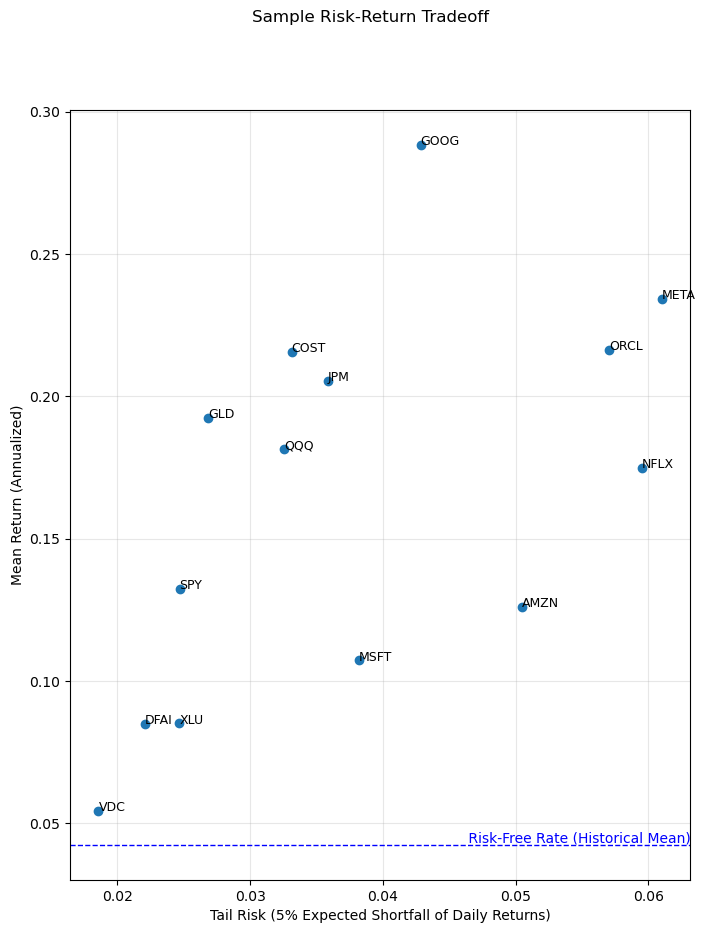

In [136]:
## make this plot a method in the class
fig, ax = plt.subplots(figsize=(8, 10))
x = -summary.loc['ES(5.0%)'] 
y = summary.loc['Mean (Ann.)']
ax.scatter(x=x, y=y)
texts = []
for t in summary.columns:
    texts.append(ax.text(x[t], y[t], t, fontsize=9))
ax.set_xlabel('Tail Risk (5% Expected Shortfall of Daily Returns)') ; ax.set_ylabel('Mean Return (Annualized)')
fig.suptitle(f'Sample Risk-Return Tradeoff')
ax.grid(True, alpha=0.3)
rf = 0.0425 # historical avg risk-free rate (10yr treasury YTM)
ax.axhline(y=rf, color='blue', linestyle='--', linewidth=1)
ax.text(
    ax.get_xlim()[1],
    rf,
    " Risk-Free Rate (Historical Mean)",
    color="blue",
    va="bottom",
    ha="right",
    fontsize=10
)
ax = plt.gca()
ax.yaxis.set_major_locator(MultipleLocator(0.05))

plt.show()


In [ ]:
y[y < 0]

symbol
IEI    -0.019174
SCHQ   -0.078240
VCLT   -0.059115
VGLT   -0.076607
Name: Mean (Ann.), dtype: float64

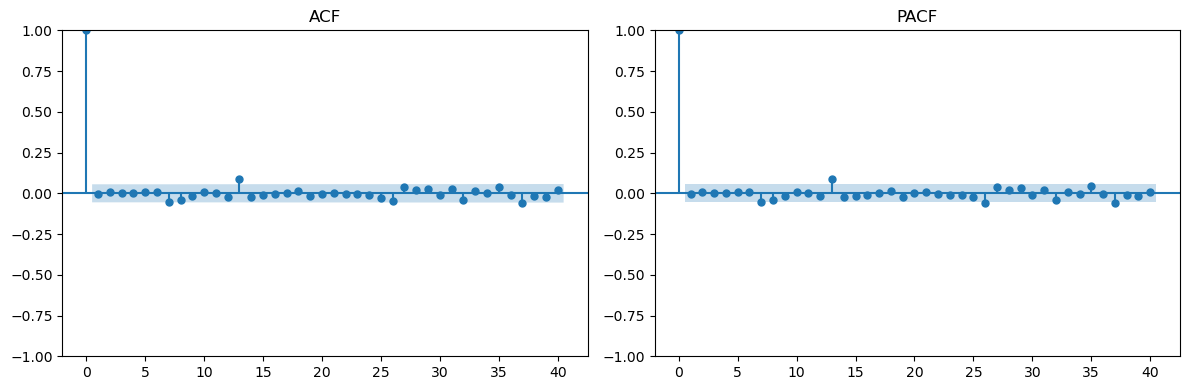

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

# Plot ACF and PACF for returns
log_returns = p.returns(log=True).dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(log_returns.iloc[:, 0], lags=40, ax=axes[0])
axes[0].set_title('ACF')

plot_pacf(log_returns.iloc[:, 0], lags=40, ax=axes[1])
axes[1].set_title('PACF')

plt.tight_layout()
plt.show()

In [138]:
round(p.dependence(), 2)

symbol,AMZN,COST,DFAI,GLD,GOOG,JPM,META,MSFT,NFLX,ORCL,QQQ,SPY,VDC,XLU
symbol,,,,,,,,,,,,,,
AMZN,1.00,0.39,0.50,0.06,0.62,0.36,0.60,0.62,0.46,0.31,0.76,0.71,0.27,0.19
COST,0.39,1.00,0.37,0.05,0.33,0.26,0.32,0.40,0.31,0.18,0.51,0.53,0.65,0.33
DFAI,0.50,0.37,1.00,0.34,0.49,0.56,0.44,0.47,0.34,0.34,0.72,0.80,0.50,0.43
GLD,0.06,0.05,0.34,1.00,0.11,0.04,0.06,0.07,0.08,0.08,0.14,0.14,0.10,0.21
GOOG,0.62,0.33,0.49,0.11,1.00,0.32,0.54,0.57,0.36,0.30,0.72,0.68,0.26,0.20
JPM,0.36,0.26,0.56,0.04,0.32,1.00,0.30,0.30,0.24,0.24,0.48,0.62,0.36,0.29
META,0.60,0.32,0.44,0.06,0.54,0.30,1.00,0.55,0.43,0.26,0.67,0.62,0.22,0.13
MSFT,0.62,0.40,0.47,0.07,0.57,0.30,0.55,1.00,0.42,0.45,0.75,0.71,0.29,0.20
NFLX,0.46,0.31,0.34,0.08,0.36,0.24,0.43,0.42,1.00,0.22,0.53,0.47,0.20,0.12


In [ ]:
fit = p.copula_fit(criterion="bic") # note: this can take a couple minutes for the student-t copula (TODO: rerun with updated portfolio)

In [108]:
fit["summary"]

,family,loglik,n_params,aic,bic,params,error
0,gaussian,11935.910597,6,-23859.821195,-23829.021419,"{'rho': [0.3878499747464622, 0.501325708634973...",None
1,student_t,12359.727804,154,-24411.455607,-23620.928030,"{'df': 9.199967815398153, 'rho': [0.3511587313...",None


From Sklar's theorem, for a random $d$-vector $X=(X_1,\dots,X_d)^\top$ with joint CDF $F$, copula $C$, and margins $F_i$ for $X_i$, the CDF can be decomposed into
$$
F(x) = C\Big(F_1(x_1),\dots,F_d(x_d) \Big) \quad \forall x\in\mathbb{R}^d
$$
and hence the density $f$ satisfies
$$
f(x) = {\small \frac{d}{dx}} F(x) =  c\Big(F_1(x_1),\dots,F_d(x_d)\Big) \prod_{i=1}^d f_i(x_i) \quad \forall x\in\mathbb{R}^d
$$
where $c$ is the density of the copula, i.e., 
$$ 
c(u) = {\small \frac{\partial^d}{\partial u_1 \cdots \partial u_d }} C(u)
$$

The $t$ copula with $\nu>0$ degrees of freedom and correlation matrix $P\in\mathbb{R}^{d\times d}$ can be represented by
$$
C^t_{\nu, P}(u) = \int_{-\infty}^{t^{-1}_\nu(u_1)} \cdots \int_{-\infty}^{t^{-1}_\nu(u_d)} \frac{\Gamma(\frac{\nu + d}{2})}{\Gamma(\nu/2) \sqrt{(\pi\nu)^d \det P}} 
\Big(1 + \frac{1}{\nu} x^\top P^{-1} x \Big)^{-(\nu + d)/{2}} dx \quad\quad \forall u\in(0,1)^d
$$
where $t^{-1}_\nu$ is the quantile function of a univariate $t_{(\nu)}$ distribution. 

Source: ("The $t$ Copula and Related Copulas") https://www.ressources-actuarielles.net/EXT/ISFA/1226.nsf/0/303eb11b4d617b79c1257b0800744575/$FILE/t%20copula%20demarta%20mcneil.pdf

In [110]:
fit["best_family"] # this is just based on BIC, but it might actually still be preferable to use student-t to ensure non-zero tail dependence

'gaussian'

In [115]:
student_params = fit["summary"].loc[fit["summary"]["family"] == "student_t"]["params"][1]
student_params

{'df': 9.199967815398153,
 'rho': array([ 0.35115873,  0.46523734,  0.0493906 ,  0.63117301,  0.05117534,
         0.29550613,  0.6032568 ,  0.63276282,  0.4825685 ,  0.39016041,
         0.75887946,  0.03895138,  0.69733021,  0.22262697,  0.19517282,
         0.03494627,  0.12972081,  0.31613075,  0.02309961,  0.2961081 ,
         0.07199507,  0.20368522,  0.33554493,  0.39489751,  0.34041499,
         0.21400728,  0.4747513 ,  0.05462714,  0.49090485,  0.17175874,
         0.60089459,  0.05261207,  0.27524593,  0.31857541,  0.45756343,
         0.15694212,  0.53041958,  0.45816594,  0.43513358,  0.344787  ,
         0.36666499,  0.66327394,  0.10289202,  0.76453648,  0.33860493,
         0.4460096 ,  0.10198346,  0.37420022,  0.0947465 ,  0.32402688,
         0.01601846,  0.05090678,  0.04508956,  0.06870699,  0.06371024,
         0.08974057,  0.21177464,  0.10224669,  0.22243471,  0.07922761,
         0.21611595,  0.17124659,  0.05687703,  0.27928169,  0.57535432,
         0.6060644

## Next Features for this Project
CAN DO NOW:
- fit margins to portfolio (already strated sketch of this method)
    - use margins + copula to (statically) estimate things like VaR and ES *for the portfolio random vector* $y=x^\top w$
    - TODO for this:
        - make fit_marginals() method **(DONE)**
        - make joint_pdf() and joint_cdf method which creates the joint PDF and CDF using the margins and copula 
        - make risk_measures() method which uses the joint density to output key risk measures like ES, VaR, MaxDD, etc.
            - this will rely on portfolio weights (as opposed to individual security risks as prev done)
            - UP TO HERE COULD STAND ALONE AS A PARAMETRIC EQUITY RISK ENGINE BTW (?)

AFTER FINISHING MIT FACTOR MODELING STUDYING:
- linear factor models
    - understanding portfolio risks/drivers
    - parameter reduction for covariance estimation
    - stress testing (e.g. VaR / ES under different macro shock/equity market scenarios)
- portfolio optimization
    - Mean-Var optimiziation (with different covariance matrix estimates incl. the factor model est.)
    - Mean-ES optimization
- volatility models
    - GARCH (+ dynamic mean return model -- look for examples online of what ppl use / look at Mike M's PhD paper)
    - Stochastic Vol model (Heston) - which also models returns as a whole
    - VaR / ES forecasting from the model
- genAI feature(s): 
    - RAG over market news for explaining recent portfolio movements

SEPARATE PROJECT:
- market bubble / market crash predictor
    - can try a variety of methods and/or an ensemble of them
        - the graph theory one or whatever from algebraic continuation channel,
        - the XLU/SPY z-score thiing or whatever from iPhone notes on PROJECTS

### Next: do ES-based portfolio optimization (e.g. using `cvxpy`) and test out/make portfolio-wide summaries

In [ ]:
# quantities and weights of each holding
q = {
    "DFAI":43, 
    "META":2, 
    "MSFT":3, 
    "JPM":4, 
    "SCHQ":45
}
w = {k: v/sum(q.values()) for k, v in q.items()}

# tickers
my_pft = list(w.keys())

# create instance of Portfolio class
p = Portfolio(tickers=my_pft, df=close_prices, weights=w)

- Review portfolio optimization math
    - CS 335 chapter 
    - ACTSC 372 chapter 
    - CO 372

Need to use weights not quantities. Also, we have to make an assumption about dynamic rebalancing right?

### Some Plotting (make this a method)

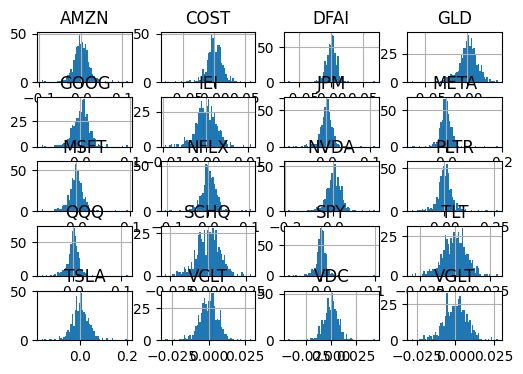

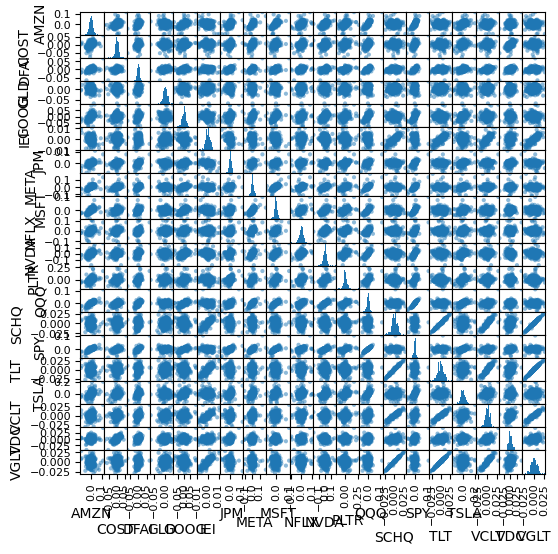

In [ ]:
# histogram of returns of each holding
log_returns = p.returns(log=True)
log_returns.hist(bins=60, figsize=(6,4))
plt.show()

# scatterplot matrix of portfolio returns
pd.plotting.scatter_matrix(log_returns, figsize=(6,6), hist_kwds={'bins':60})
plt.show()